# pandas DataFrames

**BIOS 274: Introductory Python Programming for Genomics<br>
Instructor:** Veronica Behrens<br>

<i>**Note:** Students were provided with a partially completed version of this Notebook to follow along as the instructor coded in real time and to work through practice problems independently and in small groups. The version shown here reflects the fully completed notebook after instruction.<i>

## Table of Contents
1. Pandas
2. Let's practice!

<a id="pandas"></a>
## Pandas
http://pandas.pydata.org/pandas-docs/stable/

pandas provides "fast, flexible, and expressive data structures designed to make working with “relational” or “labeled” data both easy and intuitive."<br> 

The primary data structure is the DataFrame, which is a 2-dimensional, "prettyprint" table

In [1]:
# import the pandas library
import pandas as pd

In [2]:
# initialize a DataFrame from a dictionary

myDict = {'letter':['c','a','b','d'], 'num1':[5,3,7,2], 'num2':[13,75,44,96]}

df = pd.DataFrame(myDict)
df

,letter,num1,num2
0,c,5,13
1,a,3,75
2,b,7,44
3,d,2,96


In [3]:
# initialize a DataFrame by reading from comma-delimited file
df1 = pd.read_csv('example1.csv')
df1

,name,sport,color,age
0,Bob,baseball,red,21
1,Peng,basketball,yellow,34
2,Julie,soccer,blue,27
3,Shawna,bowling,pink,43


In [4]:
# initialize a DataFrame by reading from tab-delimited file
df2 = pd.read_table('example2.tsv')
#df2 = pd.read_csv('example2.tsv', sep='\t')
df2

,name,sex
0,Peng,M
1,Julie,F
2,Shawna,F
3,Bob,M


In [5]:
# initialize a DataFrame by reading from an excel file
df3 = pd.read_excel('example3.xlsx')
#df3 = df3.dropna(axis=1)
df3

,name,occupation,kids,ID#
0,Shawna,lawyer,1,45372
1,Bob,scientist,0,32453
2,Peng,lawyer,3,12843
3,Julie,lawyer,0,21457


In [6]:
# retrieve table dimensions as tuple
print(df3.shape)

(4, 4)


In [7]:
# retrieve column names
list(df3.columns)

['name', 'occupation', 'kids', 'ID#']

In [8]:
# rename columns
df3.columns = ['name', 'job', 'children', 'ID']
df3

,name,job,children,ID
0,Shawna,lawyer,1,45372
1,Bob,scientist,0,32453
2,Peng,lawyer,3,12843
3,Julie,lawyer,0,21457


In [9]:
# retrieve data type of each column
df3.dtypes

name        object
job         object
children     int64
ID           int64
dtype: object

In [10]:
# retrieve first n rows
df3.head(2)

,name,job,children,ID
0,Shawna,lawyer,1,45372
1,Bob,scientist,0,32453


In [11]:
# retrieve last n rows
df3.tail(3)

,name,job,children,ID
1,Bob,scientist,0,32453
2,Peng,lawyer,3,12843
3,Julie,lawyer,0,21457


In [12]:
# retreive summary stats (for numerical columns)
df3.describe()

,children,ID
count,4.000000,4.000000
mean,1.000000,28031.250000
std,1.414214,14073.108929
min,0.000000,12843.000000
25%,0.000000,19303.500000
50%,0.500000,26955.000000
75%,1.500000,35682.750000
max,3.000000,45372.000000


In [13]:
# access info by column
print(df3['name'])
#print(df3.name)

#print(df3['job'])
#print(df3.job)

# accessing info in multiple columms
#df3[['name', 'job']]

0    Shawna
1       Bob
2      Peng
3     Julie
Name: name, dtype: object


In [14]:
# access info by rows

# each row has an index (often unique but not required)
# by default, integers 0...N-1

# retrieve all the row indexes
print(list(df3.index))

# access a single row
print(list(df3.loc[3]))

# access a single cell
print(df3.loc[3,'name'])

[0, 1, 2, 3]
['Julie', 'lawyer', 0, 21457]
Julie


In [15]:
# filter a dataframe: Method 1

df3[df3.children == 0]
#df3[(df3.children == 0) & (df3.job == 'scientist')]

#df3[df3.ID > 30000]
#df3[(df3.ID > 30000) | (df3.children > 0)]

,name,job,children,ID
1,Bob,scientist,0,32453
3,Julie,lawyer,0,21457


In [16]:
# filter a dataframe: Method 2

df3.query('children==0')
#df3.query("children == 0 and job=='scientist'")

#df3.query('ID>30000')
#df3.query('ID>30000 or children>0')

,name,job,children,ID
1,Bob,scientist,0,32453
3,Julie,lawyer,0,21457


In [17]:
# iterate over rows

# use df.iterrows()
# each time through, will return an index and the corresponding row

for index, row in df3.iterrows():
    #print(index)
    print(list(row))

['Shawna', 'lawyer', 1, 45372]
['Bob', 'scientist', 0, 32453]
['Peng', 'lawyer', 3, 12843]
['Julie', 'lawyer', 0, 21457]


In [18]:
# modify/add data

# can add columns to existing dataframe
df3['A'] = True
df3['B'] = [66, 44, 33, 88]
df3['C'] = ['hi', 'this', 'is', 'pandas']

# can remove columns from an existing dataframe
df3 = df3.drop(columns=['C'])

df3

,name,job,children,ID,A,B
0,Shawna,lawyer,1,45372,True,66
1,Bob,scientist,0,32453,True,44
2,Peng,lawyer,3,12843,True,33
3,Julie,lawyer,0,21457,True,88


In [19]:
# merge two dataframes (on the indexes or on a certain column)

# can provide how= ('left', 'right', 'inner', 'outer')
# pd.merge(df_left, df_right, how)

df23 = pd.merge(df2, df3, on='name')
df23

df123 = pd.merge(df1, df23, on='name')
df123 = df123[['name', 'sex', 'age', 'job', 'children', 'sport', 'ID']] # reorder and eliminate some columns
df123

,name,sex,age,job,children,sport,ID
0,Bob,M,21,scientist,0,baseball,32453
1,Peng,M,34,lawyer,3,basketball,12843
2,Julie,F,27,lawyer,0,soccer,21457
3,Shawna,F,43,lawyer,1,bowling,45372


In [20]:
# generate a grouped representation of the table and get summary statistics

df123.groupby('job').describe()
#df123.groupby('job').agg('mean')

#df123.groupby('sex').describe()
#df123.groupby('sex').agg('sum')

ID                                                         \
          count          mean           std      min      25%      50%   
job                                                                      
lawyer      3.0  26557.333333  16853.605262  12843.0  17150.0  21457.0   
scientist   1.0  32453.000000           NaN  32453.0  32453.0  32453.0   

                              age            ...              children  \
               75%      max count       mean ...    75%   max    count   
job                                          ...                         
lawyer     33414.5  45372.0   3.0  34.666667 ...   38.5  43.0      3.0   
scientist  32453.0  32453.0   1.0  21.000000 ...   21.0  21.0      1.0   

                                                        
               mean       std  min  25%  50%  75%  max  
job                                                     
lawyer     1.333333  1.527525  0.0  0.5  1.0  2.0  3.0  
scientist  0.000000       NaN  0.0  0.0  0.0  0.0  0.0  

[2 rows x 24 columns]

In [21]:
# can iterate over the groups
print('GROUPING BY JOB')
for group, df in df123.groupby('job'):
    print(group)
    print(df)
    print()
    print()
    
print('GROUPING BY SEX')
for group, df in df123.groupby('sex'):
    print(group)
    print(df)
    print()

GROUPING BY JOB
lawyer
     name sex  age     job  children       sport     ID
1    Peng   M   34  lawyer         3  basketball  12843
2   Julie   F   27  lawyer         0      soccer  21457
3  Shawna   F   43  lawyer         1     bowling  45372


scientist
  name sex  age        job  children     sport     ID
0  Bob   M   21  scientist         0  baseball  32453


GROUPING BY SEX
F
     name sex  age     job  children    sport     ID
2   Julie   F   27  lawyer         0   soccer  21457
3  Shawna   F   43  lawyer         1  bowling  45372

M
   name sex  age        job  children       sport     ID
0   Bob   M   21  scientist         0    baseball  32453
1  Peng   M   34     lawyer         3  basketball  12843



In [22]:
# do math on the columns!
#df123['children'] + df123['age']
df123['ID'] * df123['age']

0     681513
1     436662
2     579339
3    1950996
dtype: int64

In [23]:
# can sort a DataFrame
df123 = df123.sort_values(['children', 'age'])
df123

,name,sex,age,job,children,sport,ID
0,Bob,M,21,scientist,0,baseball,32453
2,Julie,F,27,lawyer,0,soccer,21457
3,Shawna,F,43,lawyer,1,bowling,45372
1,Peng,M,34,lawyer,3,basketball,12843


In [24]:
# write a pandas dataframe to a comma delimited, tab delimited, or Excel file
df123.to_csv('example123.csv', index=False)
df123.to_csv('example123.tsv', sep='\t', index=False)
df123.to_excel('example123.xlsx', index=False)

<a id="practice"></a>
## Let's practice!

In [25]:
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import pandas as pd
import seaborn as sns

### Exercise 1

**1.a.** Let's revisit the mouse tumor drug experiment from yesterday!<br><br>
>- Save the information in <code>mouseTumorDrugExperiment.txt</code> in a pandas DataFrame called <code>mouse_df</code>
>- Use <code>df.groupby()</code> to separate the mice based on genotype.
>- Find summary statistics for each genotype using <code>df.describe()</code>
>- Try to access just the mean of the tumor weight for each genotype

In [26]:
# YOUR SOLUTION HERE

inFileName = 'mouseTumorDrugExperiment.txt'

mouse_df = pd.read_table(inFileName)
mouse_df.head()

,mouseID,genotype,sex,drug_treatment,weight (g),life_span (days),tumor_weight (g)
0,1,WT,F,N,29,30,0.00
1,2,WT,F,N,30,30,0.00
2,3,WT,M,Y,30,29,0.00
3,4,WT,F,Y,28,30,0.00
4,5,Mut,M,Y,34,12,0.87


In [27]:
for group, df in mouse_df.groupby('genotype'):
    print(group)
    print(df.describe().loc['mean', 'tumor_weight (g)'])
    print()

Mut
1.198

WT
0.017499999999999998



**1.b.** Using pandas, scale the tumor weight based on the body weight of the mouse.<br>
Add a column called <code>scaled_tumor_weight (g)</code> to <code>mouse_df</code>

In [28]:
# YOUR SOLUTION HERE

# do (tumor weight column) / (body weight column)
scaledTumorWeight = mouse_df['tumor_weight (g)'] / mouse_df['weight (g)']

# add this new column to your dataframe
mouse_df['scaled_tumor_weight (g)'] = scaledTumorWeight

mouse_df.to_csv('mouseExperimentWithScaled.txt', sep='\t')
mouse_df.head()

,mouseID,genotype,sex,drug_treatment,weight (g),life_span (days),tumor_weight (g),scaled_tumor_weight (g)
0,1,WT,F,N,29,30,0.00,0.000000
1,2,WT,F,N,30,30,0.00,0.000000
2,3,WT,M,Y,30,29,0.00,0.000000
3,4,WT,F,Y,28,30,0.00,0.000000
4,5,Mut,M,Y,34,12,0.87,0.025588


### Exercise 2

Let's analyze some RNA-seq TPM data from four heart samples and four stomach samples!

I've provided you with 3 files: <code>TPM.tsv</code>, and <code>geneCoords.tsv</code>, <code>genesOfInterest.txt</code>

In [29]:
# File names

tpmFileName = 'TPM.tsv'
coordsFileName = 'geneCoords.tsv'
genesOfInterestFileName = 'genesOfInterest10.txt'

**2.a.** Store each file as a pandas DataFrame

In [30]:
# YOUR SOLUTION HERE

tpm_df = pd.read_table(tpmFileName)
tpm_df.head()

,geneID,heart1,heart2,heart3,heart4,stomach1,stomach2,stomach3,stomach4
0,ENSG00000078808,2.227539,1.642180,3.069692,5.876862,7.984645,6.109694,9.809024,16.509163
1,ENSG00000176022,3.299249,4.833141,5.366561,4.467030,0.302727,0.624891,0.331845,2.904279
2,ENSG00000160087,1.144862,0.984681,1.533869,3.127246,4.913107,3.640601,4.971402,11.179458
3,ENSG00000131584,0.272176,0.140457,0.484828,0.611995,1.076765,0.493926,0.918039,0.860849
4,ENSG00000169972,1.685734,0.621376,1.451906,3.898723,2.773391,1.789017,4.750243,7.275394


In [31]:
coords_df = pd.read_table(coordsFileName)
coords_df.head()

,chr,start,end,geneID,geneName
0,1,975204,982093,ENSG00000187642,PERM1
1,1,1070966,1074307,ENSG00000237330,RNF223
2,1,1167104,1167198,ENSG00000207730,MIR200B
3,1,1167863,1167952,ENSG00000207607,MIR200A
4,1,1211326,1214138,ENSG00000186827,TNFRSF4


In [32]:
genesOfInterest_df = pd.read_table(genesOfInterestFileName, header=None)
genesOfInterest_df.columns = ['geneID']
genesOfInterest_df.head()

,geneID
0,ENSG00000144381
1,ENSG00000115386
2,ENSG00000105063
3,ENSG00000132591
4,ENSG00000167986


**2.b.** Associate the appropriate gene name with each row in <code>tpm_df</code>

In [33]:
# YOUR SOLUTION HERE

tpm_df = pd.merge(tpm_df, coords_df)
tpm_df = tpm_df.drop(['chr', 'start', 'end'], axis=1)
tpm_df.head()

,geneID,heart1,heart2,heart3,heart4,stomach1,stomach2,stomach3,stomach4,geneName
0,ENSG00000078808,2.227539,1.642180,3.069692,5.876862,7.984645,6.109694,9.809024,16.509163,SDF4
1,ENSG00000176022,3.299249,4.833141,5.366561,4.467030,0.302727,0.624891,0.331845,2.904279,B3GALT6
2,ENSG00000160087,1.144862,0.984681,1.533869,3.127246,4.913107,3.640601,4.971402,11.179458,UBE2J2
3,ENSG00000131584,0.272176,0.140457,0.484828,0.611995,1.076765,0.493926,0.918039,0.860849,ACAP3
4,ENSG00000169972,1.685734,0.621376,1.451906,3.898723,2.773391,1.789017,4.750243,7.275394,PUSL1


**2.c.**
>- Which sample (heart1, heart2, stomach1, etc.) has the highest mean expression over all genes?<br>
>- Which gene has the highest experession across all tissues?

In [34]:
# YOUR SOLUTION HERE

tpm_df.describe()

,heart1,heart2,heart3,heart4,stomach1,stomach2,stomach3,stomach4
count,13206.000000,13206.000000,13206.000000,13206.000000,13206.000000,13206.000000,13206.000000,13206.000000
mean,18.579445,19.000438,19.696372,22.992794,28.674269,29.495784,30.566489,36.414694
std,114.228867,110.415610,102.749480,78.129466,125.565990,138.156844,132.570742,146.766512
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003261
25%,0.928369,0.781805,1.092325,1.432943,1.057298,0.919470,1.250655,1.930552
50%,4.478434,4.181761,5.113805,6.927422,5.641287,5.207507,6.577250,9.143479
75%,14.251661,14.274683,15.582146,20.716998,20.147003,19.539151,21.881680,29.240628
max,10516.274619,9569.975617,8702.074106,3780.834357,4336.828225,5615.933964,5281.438335,5555.846107


In [35]:
tpm_df.max(axis=0)

geneID      ENSG00000284917
heart1              10516.3
heart2              9569.98
heart3              8702.07
heart4              3780.83
stomach1            4336.83
stomach2            5615.93
stomach3            5281.44
stomach4            5555.85
geneName              ZZEF1
dtype: object

**2.d.** We're only interested in the genes in <code>genesOfInterest.txt</code>.<br>
>- Generate a DataFrame called <code>tpm_genesOfInterest_df</code> that has the geneName (as the index), geneID, and TPM values for ONLY the genes in <code>genesOfInterest.txt</code>

>- Set the geneName as the index of <code>tpm_genesOfInterest_df</code>

>- Write the information in <code>tpm_genesOfInterest_df</code> to a file called <code>tpm_genesOfInterest.tsv</code>

In [36]:
# YOUR SOLUTION HERE

tpm_genesOfInterest_df = pd.merge(tpm_df, genesOfInterest_df)

tpm_genesOfInterest_df = tpm_genesOfInterest_df.set_index('geneName')
tpm_genesOfInterest_df.head()

,geneID,heart1,heart2,heart3,heart4,stomach1,stomach2,stomach3,stomach4
geneName,,,,,,,,,
PAFAH2,ENSG00000158006,5.001504,6.533248,6.596236,11.995769,7.722996,9.353647,11.402982,17.294510
SNORA44,ENSG00000273544,0.000000,7.030024,4.977679,5.445522,4.540902,7.030024,14.933038,5.445522
DNALI1,ENSG00000163879,6.053177,3.470838,6.414236,8.307599,3.048940,5.477803,4.580065,9.479395
NDC1,ENSG00000058804,88.479934,89.513354,90.784728,100.507271,73.848413,77.071530,76.684280,100.443685
WDR63,ENSG00000162643,0.687559,0.394240,0.251231,0.366459,0.232867,0.240343,0.000000,0.139629


In [37]:
# Now, you can look up the expression level of a particular gene in your DataFrame!
tpm_genesOfInterest_df.loc['SURF1']

geneID      ENSG00000148290
heart1              19.2311
heart2               14.579
heart3              28.1701
heart4              37.5528
stomach1            31.3046
stomach2            37.0684
stomach3            36.7099
stomach4            66.3516
Name: SURF1, dtype: object

**2.e.** Make a clustered heatmap of the TPM values for the genes of interest.<br>
Save your heatmap to a file.

In [38]:
# YOUR SOLUTION HERE

forPlotting_df = tpm_genesOfInterest_df.drop(['geneID'], axis=1)
forPlotting_df.head()

,heart1,heart2,heart3,heart4,stomach1,stomach2,stomach3,stomach4
geneName,,,,,,,,
PAFAH2,5.001504,6.533248,6.596236,11.995769,7.722996,9.353647,11.402982,17.294510
SNORA44,0.000000,7.030024,4.977679,5.445522,4.540902,7.030024,14.933038,5.445522
DNALI1,6.053177,3.470838,6.414236,8.307599,3.048940,5.477803,4.580065,9.479395
NDC1,88.479934,89.513354,90.784728,100.507271,73.848413,77.071530,76.684280,100.443685
WDR63,0.687559,0.394240,0.251231,0.366459,0.232867,0.240343,0.000000,0.139629


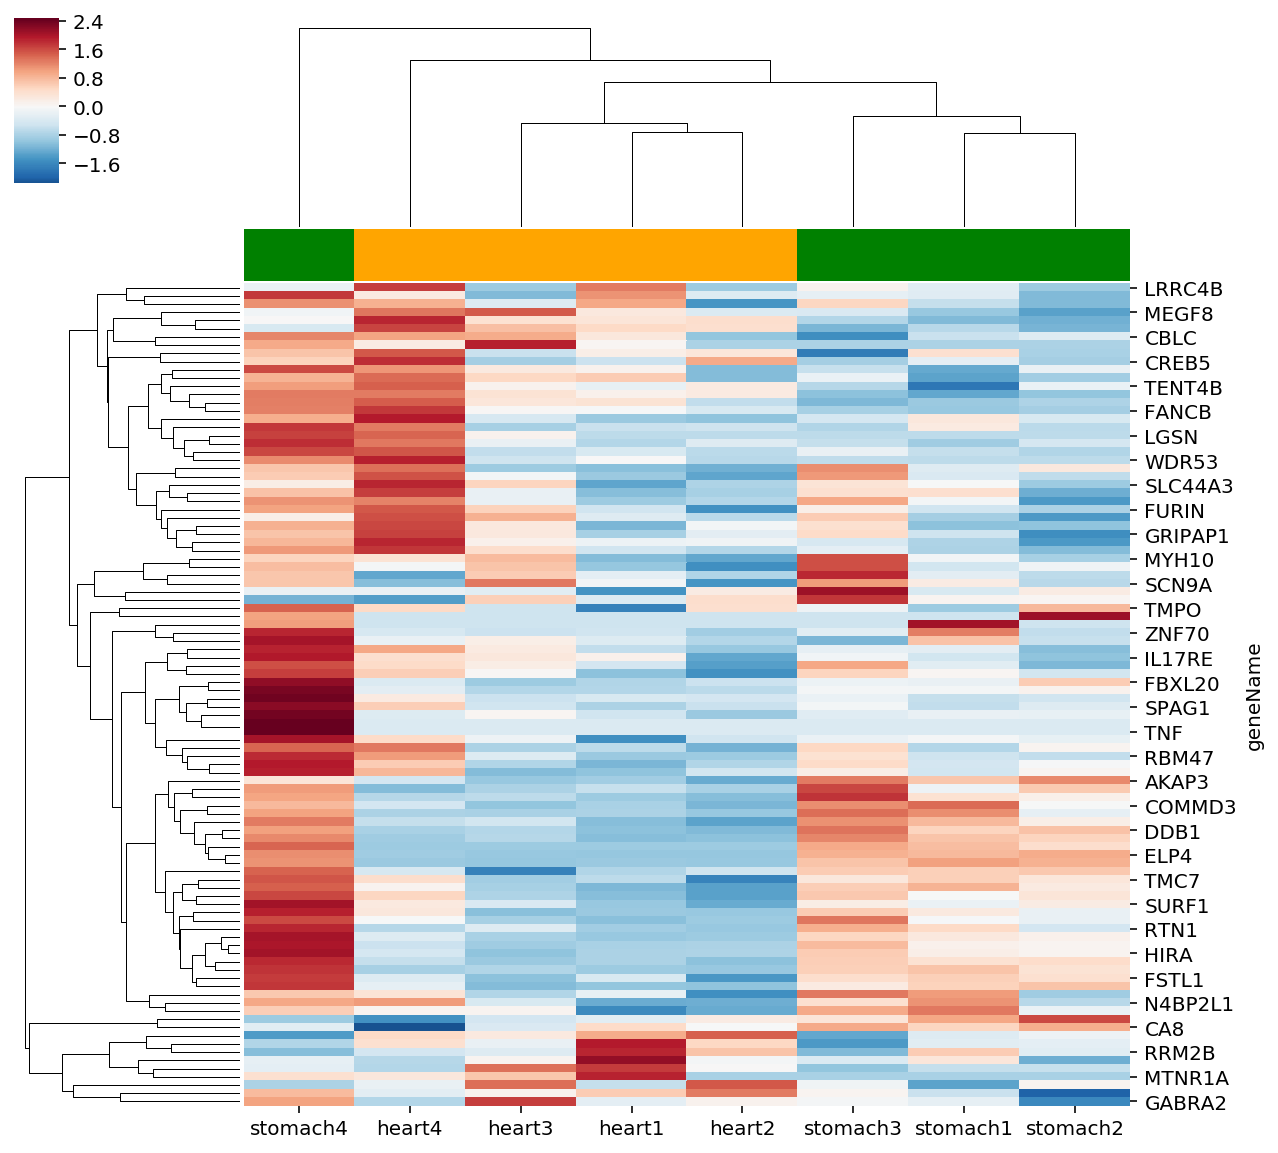

In [39]:
sns.clustermap(data=forPlotting_df, z_score=0, center=0,
               cmap = 'RdBu_r',
               col_colors=['orange']*4 + ['green']*4)

plt.show()